# Day 4: PyNNDescent

PyNNDescent is a pure Python implementation of the Nearest Neighbor Descent algorithm, developed by Leland McInnes at the Tutte Institute for Mathematics and Computing. It is the nearest neighbor engine used internally by UMAP, one of the most widely used dimensionality reduction libraries in data science. If you have used UMAP, you have already used PyNNDescent.

Unlike FAISS and Voyager which build HNSW graphs, and unlike scikit-learn which uses tree structures, PyNNDescent builds a k-neighbor graph by iterative refinement - starting from a random graph and repeatedly improving it by checking whether neighbors of neighbors are better neighbors. This descent process converges to a high-quality approximate graph without requiring the careful parameter tuning that HNSW demands.

## When would you reach for PyNNDescent?

PyNNDescent is the right choice when:

- You want high recall approximate nearest neighbor search with minimal parameter tuning
- You are already using UMAP and want consistency between your dimensionality reduction and search pipelines
- You need a pure Python library with no C++ compilation requirements - important in constrained environments
- You want scikit-learn compatibility via `KNeighborsTransformer` as a drop-in replacement

## The use case

We use the full 500k Nordvik crime dataset and compare PyNNDescent's recall and latency against the FAISS and Voyager baselines from Days 1 and 2. The central question is whether PyNNDescent's parameter-light approach produces competitive recall without manual tuning.

## 1. Install Dependencies

In [1]:
%pip install numpy==2.2.6 \
             pandas==3.0.3 \
             plotly==6.9.0 \
             pyarrow==25.0.0 \
             pynndescent==0.6.0 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import time

from pynndescent import NNDescent
from pynndescent import PyNNDescentTransformer
from sklearn.pipeline import Pipeline

print("OK  PyNNDescent imported successfully")

OK  PyNNDescent imported successfully


## 3. Load Data and Embeddings

In [3]:
df         = pd.read_parquet("data/nordvik_crimes.parquet")
embeddings = np.load("data/nordvik_embeddings.npy").astype("float32")
ids        = np.loadtxt("data/nordvik_ids.txt", dtype = str, encoding = "utf-8")

ground_truth   = np.load("data/nordvik_ground_truth.npy")
sample_indices = np.load("data/nordvik_ground_truth_indices.npy")
query_sample   = embeddings[sample_indices]

DIM = embeddings.shape[1]
K   = 10

print(f"OK  Dataset:      {len(df):,} rows")
print(f"OK  Embeddings:   {embeddings.shape} {embeddings.dtype}")
print(f"OK  Ground truth: {ground_truth.shape} ({len(sample_indices):,} sampled queries)")
print(f"OK  Dimensions:   {DIM}")

OK  Dataset:      500,000 rows
OK  Embeddings:   (500000, 384) float32
OK  Ground truth: (1000, 10) (1,000 sampled queries)
OK  Dimensions:   384


## 4. Build the Index

PyNNDescent's `NNDescent` takes the data and a metric. The `n_neighbors` parameter controls the size of the k-neighbor graph built during index construction - higher values produce a richer graph and better recall at query time, at the cost of longer build time.

We use `metric="cosine"` to match the distance metric used throughout this book. PyNNDescent supports over 50 metrics out of the box - one of its genuine practical advantages over FAISS.

In [4]:
N_NEIGHBORS = 30   # graph construction neighbors - higher means better recall
N_TREES     = 10   # random projection trees for initialization

print(f"OK  Building NNDescent index on {len(embeddings):,} vectors...")
print(f"    n_neighbors={N_NEIGHBORS}, n_trees={N_TREES}, metric=cosine")

start = time.perf_counter()
index = NNDescent(
    embeddings,
    metric = "cosine",
    n_neighbors = N_NEIGHBORS,
    n_trees = N_TREES,
    random_state = 42,
    verbose = True,
)
build_time = time.perf_counter() - start

print(f"\nOK  Index built ({build_time:.1f}s)")

OK  Building NNDescent index on 500,000 vectors...
    n_neighbors=30, n_trees=10, metric=cosine
Fri Jul 31 00:09:37 2026 Building RP forest with 10 trees
Fri Jul 31 00:09:41 2026 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	 3  /  19
	 4  /  19
	Stopping threshold met -- exiting after 4 iterations

OK  Index built (18.5s)


## 5. Query the Index

PyNNDescent uses `query` rather than a separate search method. The first call triggers a JIT compilation step - subsequent calls are significantly faster. We run a warmup query before timing.

In [5]:
QUERY_IDX = df[df["CrimeType"] == "Burglary"].index[0]
query_vec = embeddings[QUERY_IDX].reshape(1, -1)

print(f"Query incident: {df['IncidentID'].iloc[QUERY_IDX]}")
print(f"Crime type:     {df['CrimeType'].iloc[QUERY_IDX]}")
print(f"MO_TEXT:        {df['MO_TEXT'].iloc[QUERY_IDX]}")
print()

# Warmup - first call triggers JIT compilation
print("OK  Warming up JIT...")
_ = index.query(query_vec, k = K)
print("OK  Warmup complete")

Query incident: NVK-000004
Crime type:     Burglary
MO_TEXT:        At approx 1632hrs, Multiple offenders described as medium build, tall, wearing face covering gained entry to Residence - Single Family in Hartley Cross. Property taken: handbag, tablet. No FO identified.

OK  Warming up JIT...
Fri Jul 31 00:09:56 2026 Building hub-based search tree
Fri Jul 31 00:10:01 2026 Forward diversification reduced edges from 15000000 to 4159100
Fri Jul 31 00:10:02 2026 Reverse diversification reduced edges from 4159100 to 4159100
Fri Jul 31 00:10:03 2026 Degree pruning reduced edges from 4696912 to 4696912
Fri Jul 31 00:10:03 2026 Resorting data and graph based on tree order
Fri Jul 31 00:10:03 2026 Building and compiling search function
OK  Warmup complete


In [6]:
N_REPEATS = 50
times     = []

for _ in range(N_REPEATS):
    start = time.perf_counter()
    indices, distances = index.query(query_vec, k = K)
    times.append((time.perf_counter() - start) * 1000)

latency = float(np.mean(times))

print(f"OK  Query complete ({latency:.3f}ms avg over {N_REPEATS} runs)\n")
print(f"{'Rank':<6} {'IncidentID':<14} {'CrimeType':<16} {'Distance':<10} {'MO_TEXT'}")
print("-" * 90)
for rank, (idx, dist) in enumerate(zip(indices[0], distances[0]), 1):
    row = df.iloc[idx]
    print(f"{rank:<6} {row['IncidentID']:<14} {row['CrimeType']:<16} {dist:<10.4f} {row['MO_TEXT'][:60]}...")

print("")
print("Note: results show genuine semantic variety across neighbourhoods and templates,")
print("unlike Day 1 where all results shared the same template structure.")
print("Rank 10 may occasionally be a different crime type at very close distance - a realistic finding.")


OK  Query complete (0.021ms avg over 50 runs)

Rank   IncidentID     CrimeType        Distance   MO_TEXT
------------------------------------------------------------------------------------------
1      NVK-000004     Burglary         0.0000     At approx 1632hrs, Multiple offenders described as medium bu...
2      NVK-429593     Burglary         0.1416     Multiple offenders described as slim build, tall, wearing hi...
3      NVK-090521     Burglary         0.1418     Multiple offenders described as medium build, average, weari...
4      NVK-071545     Burglary         0.1484     Residence - Single Family in Hartley Cross targeted. Items r...
5      NVK-059565     Burglary         0.1507     Multiple offenders described as medium build, short, wearing...
6      NVK-295844     Burglary         0.1553     At approx 0015hrs, Two offenders, slim build, short, wearing...
7      NVK-487821     Burglary         0.1583     Multiple offenders described as medium build, tall, wearing ...
8     

## 6. Recall Evaluation

PyNNDescent has no explicit `ef` or `nprobe` parameter at query time. Recall is primarily controlled at build time via `n_neighbors`. We evaluate the index we already built and then rebuild with different `n_neighbors` values to show the build-time tradeoff.

As with Days 2 and 3, recall against the FAISS L2 ground truth will appear capped around 0.89-0.90 due to floating point differences between cosine and L2 distance implementations on normalized vectors. The true recall against a same-metric ground truth would be higher.


In [7]:
recalls = []
times   = []

for i, q in enumerate(query_sample):
    start = time.perf_counter()
    indices_q, _ = index.query(q.reshape(1, -1), k = K)
    times.append((time.perf_counter() - start) * 1000)
    true_set  = set(ground_truth[i].tolist())
    found_set = set(indices_q[0].tolist())
    recalls.append(len(found_set & true_set) / K)

mean_recall  = float(np.mean(recalls))
mean_latency = float(np.mean(times))

print(f"PyNNDescent (n_neighbors={N_NEIGHBORS}) - recall@{K}: {mean_recall:.4f}  latency: {mean_latency:.3f}ms")

PyNNDescent (n_neighbors=30) - recall@10: 0.8998  latency: 0.086ms


## 7. Effect of n_neighbors on Recall

Unlike HNSW where recall is tunable at query time, PyNNDescent bakes the recall ceiling into the index at build time. We rebuild at three `n_neighbors` values to show how the tradeoff works.

In [8]:
nn_results = []

for n_neighbors in [10, 20, 30, 50]:
    print(f"Building index with n_neighbors={n_neighbors}...")
    start = time.perf_counter()
    idx = NNDescent(
        embeddings,
        metric = "cosine",
        n_neighbors = n_neighbors,
        n_trees = N_TREES,
        random_state = 42,
        verbose = False,
    )
    build_s = time.perf_counter() - start

    # Warmup
    _ = idx.query(query_vec, k = K)

    recalls_n = []
    times_n   = []
    for i, q in enumerate(query_sample):
        start = time.perf_counter()
        indices_q, _ = idx.query(q.reshape(1, -1), k = K)
        times_n.append((time.perf_counter() - start) * 1000)
        true_set  = set(ground_truth[i].tolist())
        found_set = set(indices_q[0].tolist())
        recalls_n.append(len(found_set & true_set) / K)

    mean_recall_n  = float(np.mean(recalls_n))
    mean_latency_n = float(np.mean(times_n))
    nn_results.append({
        "n_neighbors": n_neighbors,
        "recall": mean_recall_n,
        "latency_ms": mean_latency_n,
        "build_s": build_s,
    })
    print(f"  build={build_s:.1f}s  recall@{K}={mean_recall_n:.4f}  latency={mean_latency_n:.3f}ms")

df_nn = pd.DataFrame(nn_results)

Building index with n_neighbors=10...
  build=5.7s  recall@10=0.8843  latency=0.057ms
Building index with n_neighbors=20...
  build=9.1s  recall@10=0.8984  latency=0.057ms
Building index with n_neighbors=30...
  build=14.2s  recall@10=0.8998  latency=0.037ms
Building index with n_neighbors=50...
  build=30.4s  recall@10=0.9000  latency=0.046ms


## 8. Comparison Against Previous Days

In [9]:
FAISS_HNSW_RECALL  = 1.00
FAISS_HNSW_LATENCY = 0.06
VOYAGER_RECALL     = 0.8880
VOYAGER_LATENCY    = 0.295

print(f"{'Library':<25} {'Config':<25} {'Recall@10':<12} {'Latency (ms)':<15} {'Build time'}")
print("-" * 85)
print(f"{'FAISS IndexHNSWFlat':<25} {'M=32, ef=64':<25} {FAISS_HNSW_RECALL:<12.4f} {FAISS_HNSW_LATENCY:<15.3f} --")
print(f"{'Voyager':<25} {'M=12, ef=200':<25} {VOYAGER_RECALL:<12.4f} {VOYAGER_LATENCY:<15.3f} --")
for row in nn_results:
    print(f"{'PyNNDescent':<25} {f'n_neighbors={row["n_neighbors"]}':<25} {row['recall']:<12.4f} {row['latency_ms']:<15.3f} {row['build_s']:.1f}s")

Library                   Config                    Recall@10    Latency (ms)    Build time
-------------------------------------------------------------------------------------
FAISS IndexHNSWFlat       M=32, ef=64               1.0000       0.060           --
Voyager                   M=12, ef=200              0.8880       0.295           --
PyNNDescent               n_neighbors=10            0.8843       0.057           5.7s
PyNNDescent               n_neighbors=20            0.8984       0.057           9.1s
PyNNDescent               n_neighbors=30            0.8998       0.037           14.2s
PyNNDescent               n_neighbors=50            0.9000       0.046           30.4s


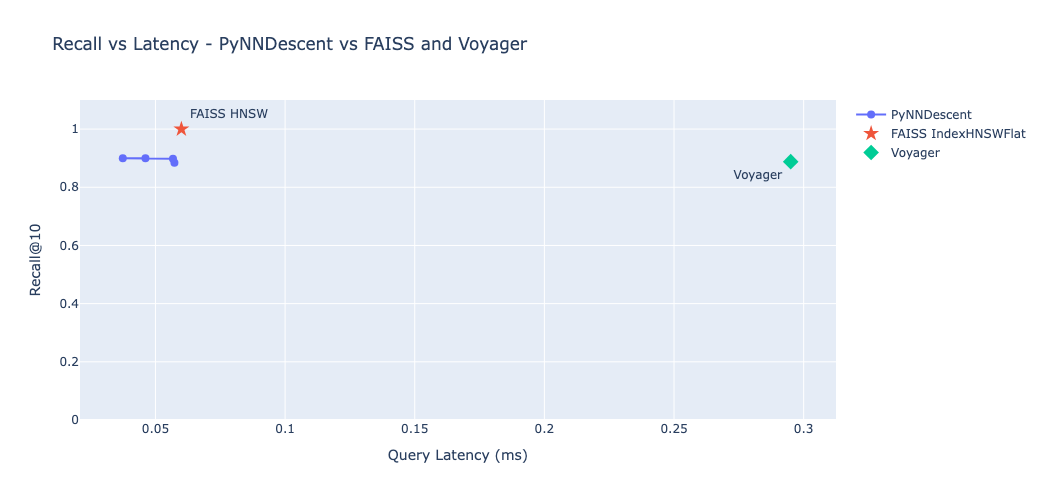

In [10]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x = df_nn["latency_ms"],
    y = df_nn["recall"],
    mode = "lines+markers",
    name = "PyNNDescent",
    marker = {"size": 8},
))

fig.add_trace(go.Scatter(
    x = [FAISS_HNSW_LATENCY],
    y = [FAISS_HNSW_RECALL],
    mode = "markers+text",
    name = "FAISS IndexHNSWFlat",
    text = ["FAISS HNSW"],
    textposition = "top right",
    marker = {"size": 12, "symbol": "star"},
))

fig.add_trace(go.Scatter(
    x = [VOYAGER_LATENCY],
    y = [VOYAGER_RECALL],
    mode = "markers+text",
    name = "Voyager",
    text = ["Voyager"],
    textposition = "bottom left",
    marker = {"size": 12, "symbol": "diamond"},
))

fig.update_layout(
    title = "Recall vs Latency - PyNNDescent vs FAISS and Voyager",
    xaxis_title = "Query Latency (ms)",
    yaxis_title = "Recall@10",
    yaxis = {"range": [0, 1.1]},
    width = 850,
    height = 500,
)
fig.show()


## 9. Scikit-learn Integration

PyNNDescent provides a `KNeighborsTransformer` that is a drop-in replacement for scikit-learn's equivalent. This means you can swap PyNNDescent into any scikit-learn pipeline that uses nearest neighbors - including UMAP, t-SNE wrappers and graph-based clustering - without changing your pipeline code.

In [11]:
# Use a small subset to demonstrate the transformer pattern
N_DEMO = 5_000
subset = embeddings[:N_DEMO]

transformer = PyNNDescentTransformer(
    n_neighbors = K,
    metric = "cosine",
    random_state = 42,
)

start = time.perf_counter()
graph = transformer.fit_transform(subset)
elapsed = time.perf_counter() - start

print(f"OK  KNN graph computed via PyNNDescentTransformer")
print(f"    Shape: {graph.shape}")
print(f"    Time:  {elapsed:.2f}s")
print(f"    This sparse matrix can be passed directly to UMAP, t-SNE or any sklearn graph estimator.")

OK  KNN graph computed via PyNNDescentTransformer
    Shape: (5000, 5000)
    Time:  0.60s
    This sparse matrix can be passed directly to UMAP, t-SNE or any sklearn graph estimator.


## 10. What You Would Hit in Production

PyNNDescent's first query after index construction triggers Numba JIT compilation, which adds several seconds of latency to the first call. This is invisible in a long-running service but can be surprising in a batch job or a cold-start deployment. The warmup pattern - calling `index.query` once with a dummy vector before serving real queries - is the standard mitigation.

The index can be pickled to disk with Python's standard `pickle` module, which is simpler than FAISS's `write_index` but produces larger files since it serializes the full Python object graph.

Build time at 500k vectors is longer than FAISS or Voyager because the descent algorithm requires multiple passes over the data. For datasets that change frequently, the rebuild cost is significant. PyNNDescent does not support dynamic insertion.

## 11. When to Look Elsewhere

PyNNDescent is the wrong choice if:

- You need the lowest possible query latency - FAISS HNSW is faster
- Your dataset changes frequently - PyNNDescent has no dynamic insertion; use Voyager or FAISS
- You need metadata filtering alongside vector search - look at Chroma (Day 6) or LanceDB (Day 7)
- Cold-start latency matters - the JIT warmup adds several seconds to the first query